In [11]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('nr_ic_merged.csv')

In [13]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [14]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [16]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [17]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [18]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=30, shuffle=True, random_state=42)

In [19]:
from sklearn.metrics import roc_auc_score

auc_per_fold = []

for train_index, test_index in kf.split(x):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    xgb_estimator = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        n_jobs=-1,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss"
    )

    model = OneVsRestClassifier(xgb_estimator)
    model.fit(X_train, y_train)

    y_pred_prob_matrix = model.predict_proba(X_test)

    # Compute ROC-AUC per target
    fold_scores = []
    for i in range(y.shape[1]):
        try:
            score = roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
            fold_scores.append(score)
        except ValueError:
            # Handle rare cases where a fold might miss a specific class
            fold_scores.append(0.5)

    auc_per_fold.append(fold_scores)

# Convert to array for easier statistics
auc_per_fold = np.array(auc_per_fold)

# Mean and std per target
mean_auc = np.mean(auc_per_fold, axis=0)
std_auc = np.std(auc_per_fold, axis=0)

print("Mean ROC-AUC per target:", mean_auc)
print("Std ROC-AUC per target:", std_auc)
print("Overall mean ROC-AUC:", np.mean(mean_auc))

Mean ROC-AUC per target: [0.9694761  0.97915058 0.97184629 0.98539602 0.98552943 0.95971587]
Std ROC-AUC per target: [0.01353021 0.00695967 0.00989127 0.00904304 0.01129257 0.01866606]
Overall mean ROC-AUC: 0.9751857153624938


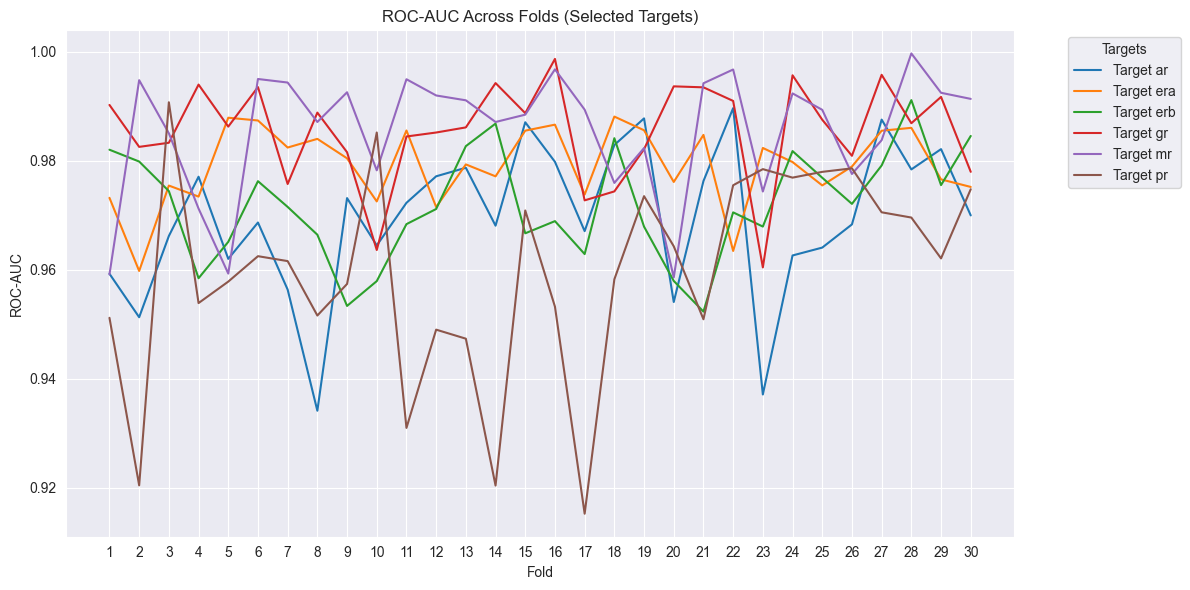

In [20]:
import matplotlib.pyplot as plt
import numpy as np

num_folds = auc_per_fold.shape[0]

num_targets = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(12, 6))

x_folds = np.arange(1, num_folds + 1)

for target_idx in num_targets:
    plt.plot(
        x_folds,
        auc_per_fold[:, target_idx],
        label=f"Target {target_names[target_idx]}"
    )

plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Folds (Selected Targets)")
plt.xticks(x_folds)  # force integer x-axis labels
plt.legend(title="Targets", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
